In [11]:
!git clone https://github.com/hriday-goyal/ozone-ai-ml.git

fatal: destination path 'ozone-ai-ml' already exists and is not an empty directory.


# Ozone Output Estimator using Machine Learning

This notebook predicts ozone output (ppm) based on input variables like voltage, time, electrode gap, temperature, and humidity using ML models.

In [12]:
import pandas as pd

df = pd.read_csv('/content/ozone-ai-ml/data/simulated_ozone_data.csv')

df.head()

,Voltage_kV,Time_min,Gap_mm,Temperature_C,Humidity_percent,Ozone_ppm
0,5.621781,19.618918,1.412495,22.534026,65.361932,36.821559
1,9.655000,3.440059,4.610212,24.178855,37.626952,6.276422
2,8.123958,5.687233,3.021009,22.655157,58.814418,10.062225
3,7.190609,27.058071,4.305830,21.330538,60.335752,30.588849
4,4.092130,18.586443,2.280198,21.809538,51.206534,21.557559


In [13]:
# Load dataset

df = pd.read_csv('/content/ozone-ai-ml/data/simulated_ozone_data.csv')

df.head()

,Voltage_kV,Time_min,Gap_mm,Temperature_C,Humidity_percent,Ozone_ppm
0,5.621781,19.618918,1.412495,22.534026,65.361932,36.821559
1,9.655000,3.440059,4.610212,24.178855,37.626952,6.276422
2,8.123958,5.687233,3.021009,22.655157,58.814418,10.062225
3,7.190609,27.058071,4.305830,21.330538,60.335752,30.588849
4,4.092130,18.586443,2.280198,21.809538,51.206534,21.557559


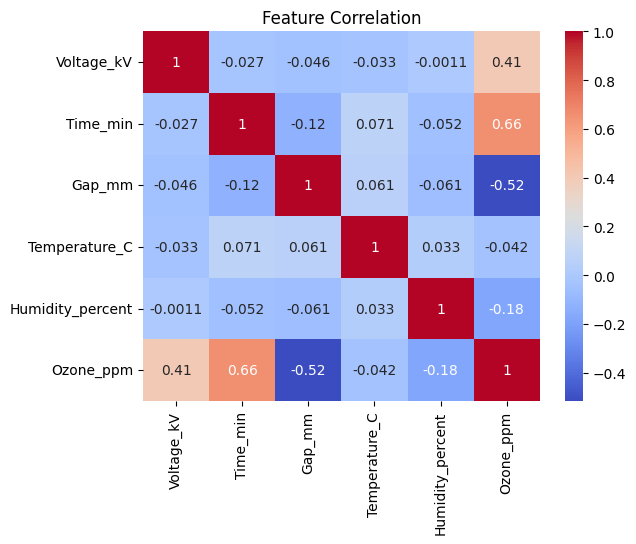

In [14]:
# Visualize correlation matrix
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [15]:
# Split data
X = df.drop('Ozone_ppm', axis=1)
y = df['Ozone_ppm']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print('Linear Regression R2:', r2_score(y_test, y_pred_lr))

Linear Regression R2: 0.8154679207585671


In [17]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest R2:', r2_score(y_test, y_pred_rf))

Random Forest R2: 0.926252634244131


In [18]:
# XGBoost Regressor
xg = xgb.XGBRegressor(n_estimators=100, random_state=42)
xg.fit(X_train, y_train)
y_pred_xg = xg.predict(X_test)
print('XGBoost R2:', r2_score(y_test, y_pred_xg))

XGBoost R2: 0.9103882634854253


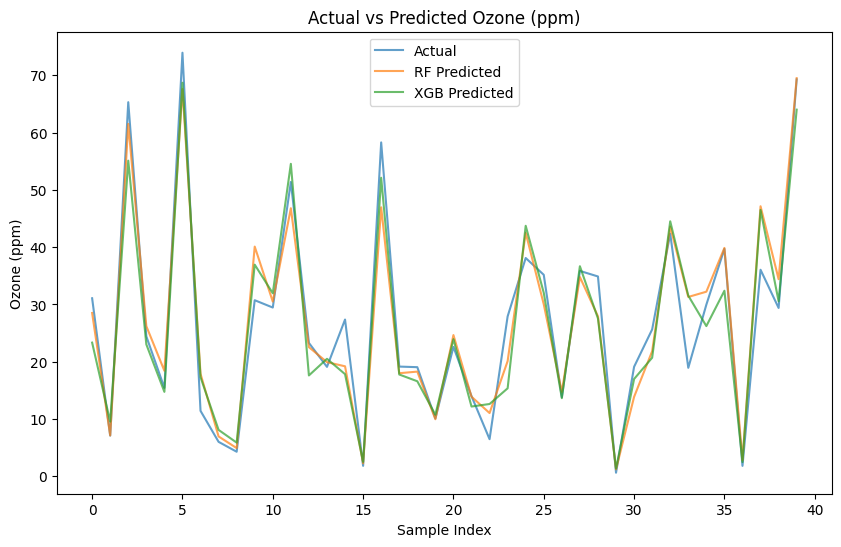

In [19]:
# Plot predictions
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual', alpha=0.7)
plt.plot(y_pred_rf, label='RF Predicted', alpha=0.7)
plt.plot(y_pred_xg, label='XGB Predicted', alpha=0.7)
plt.legend()
plt.title('Actual vs Predicted Ozone (ppm)')
plt.xlabel('Sample Index')
plt.ylabel('Ozone (ppm)')
plt.show()

In [20]:
# Complete Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MODEL PERFORMANCE")

print("\nLinear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

print("\nRandom Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

print("\nXGBoost")
print("MAE:", mean_absolute_error(y_test, y_pred_xg))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xg)))
print("R2:", r2_score(y_test, y_pred_xg))

MODEL PERFORMANCE

Linear Regression
MAE: 5.723860818810206
RMSE: 7.742370644877437
R2: 0.8154679207585671

Random Forest
MAE: 3.5030110361359674
RMSE: 4.894533175357903
R2: 0.926252634244131

XGBoost
MAE: 4.182361905954461
RMSE: 5.395360488199476
R2: 0.9103882634854253
